# Notebook 4 — Delay Classification

In [4]:
import os
import warnings
from pathlib import Path
from urllib.parse import quote_plus

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

In [5]:
env_path = Path("../.env")
load_dotenv(env_path)

db_user = quote_plus(os.getenv("DB_USER", ""))
db_password = quote_plus(os.getenv("DB_PASSWORD", ""))
db_host = os.getenv("DB_HOST", "localhost")
db_port = os.getenv("DB_PORT", "5432")
db_name = os.getenv("DB_NAME", "transitpulse")

engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)
print("Database engine and models directory are ready.")

Database engine and models directory are ready.


In [6]:
print("Loading trip-level delay data...")
delay_query = text("""
SELECT
    f.passenger_count,
    f.delay_minutes,
    t.hour,
    t.is_peak_hour,
    d.is_weekend,
    d.is_holiday,
    d.month,
    r.route_type,
    r.is_express
FROM fact_ridership f
JOIN dim_time t ON f.time_id = t.time_id
JOIN dim_date d ON f.date_id = d.date_id
JOIN dim_route r ON f.route_id = r.route_id
""")
df_delays = pd.read_sql(delay_query, engine)
print(f"Delay data shape: {df_delays.shape}")
df_delays.head()

Loading trip-level delay data...
Delay data shape: (500000, 9)


,passenger_count,delay_minutes,hour,is_peak_hour,is_weekend,is_holiday,month,route_type,is_express
0,0,19.43,15,False,False,False,7,LRT,False
1,19,22.03,6,False,False,False,12,LRT,False
2,10,6.42,0,False,True,False,8,LRT,False
3,108,6.12,19,True,False,False,3,LRT,False
4,40,0.34,10,False,False,False,6,LRT,False


In [7]:
print("Creating delay-class labels...")
conditions = [
    df_delays["delay_minutes"] == 0,
    (df_delays["delay_minutes"] > 0) & (df_delays["delay_minutes"] <= 10),
    df_delays["delay_minutes"] > 10,
]
labels = ["on_time", "minor_delay", "major_delay"]
df_delays["delay_class"] = np.select(conditions, labels, default="on_time")
print(df_delays["delay_class"].value_counts())

Creating delay-class labels...
delay_class
minor_delay    277694
major_delay    222157
on_time           149
Name: count, dtype: int64


In [8]:
print("Engineering classification features...")
df_model = pd.get_dummies(df_delays, columns=["route_type"], drop_first=True)
boolean_columns = ["is_peak_hour", "is_weekend", "is_holiday", "is_express"]
df_model[boolean_columns] = df_model[boolean_columns].astype(int)

feature_columns = [
    column for column in df_model.select_dtypes(include=[np.number, "bool"]).columns
    if column not in ["delay_minutes", "delay_class"]
]
X = df_model[feature_columns].astype(float)
y = df_model["delay_class"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Prepared {X.shape[1]} features. Classes: {class_names.tolist()}")

Engineering classification features...
Prepared 8 features. Classes: ['major_delay', 'minor_delay', 'on_time']


In [9]:
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

Splitting data into training and test sets...
Training rows: 400,000; test rows: 100,000


In [10]:
print("Training RandomForestClassifier...")
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("Training complete.")

Training RandomForestClassifier...
Training complete.


Evaluating the classifier on the test set...
              precision    recall  f1-score   support

 major_delay       0.44      0.00      0.01     44431
 minor_delay       0.56      1.00      0.71     55539
     on_time       0.00      0.00      0.00        30

    accuracy                           0.55    100000
   macro avg       0.33      0.33      0.24    100000
weighted avg       0.50      0.55      0.40    100000



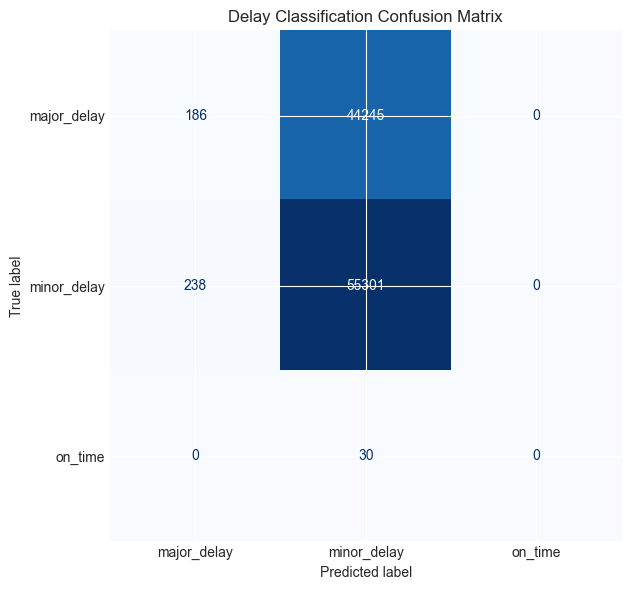

In [11]:
print("Evaluating the classifier on the test set...")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(12, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Delay Classification Confusion Matrix")
fig.tight_layout()
fig.savefig(model_dir / "delay_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Plotting feature importances...


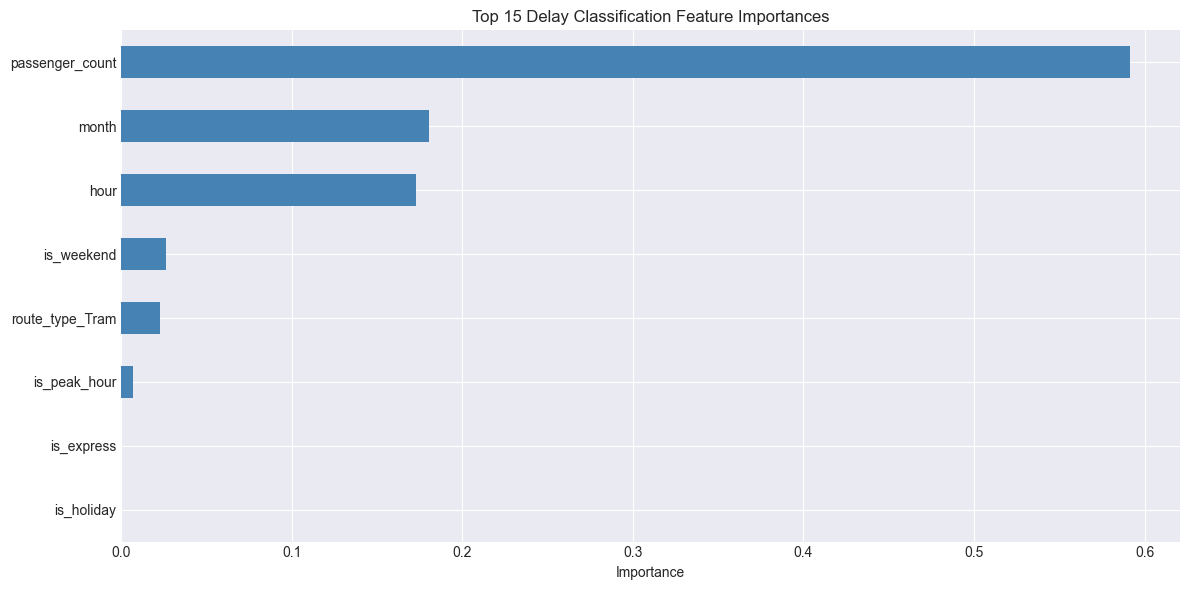

In [12]:
print("Plotting feature importances...")
feature_importance = pd.Series(model.feature_importances_, index=X.columns).nlargest(15).sort_values()
fig, ax = plt.subplots(figsize=(12, 6))
feature_importance.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 15 Delay Classification Feature Importances")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(model_dir / "delay_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
print("Running 5-fold cross-validation...")
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring="f1_weighted", n_jobs=-1)
print(f"Weighted F1 score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Running 5-fold cross-validation...
Weighted F1 score: 0.3996 ± 0.0004


In [14]:
print("Saving the classifier and label encoder...")
joblib.dump(model, model_dir / "delay_classifier.pkl")
joblib.dump(le, model_dir / "delay_label_encoder.pkl")
print("Model saved.")

Saving the classifier and label encoder...
Model saved.


## Summary

The Random Forest predicts whether a trip is on time, moderately delayed, or substantially delayed from service, calendar, route, and passenger-volume attributes. The classification report and confusion matrix show which classes are easiest to distinguish, while weighted F1 cross-validation summarizes expected performance across all classes while accounting for class imbalance. Feature importances indicate which operational factors contribute most strongly to the model's decisions.